# Notebook 2 - Exploratory Data Analysis

## Introduction

In this section, we aim to achieve the following goals:

1) First, we **provide descriptive statistics** which give a plain picture of the sample, looking at who the patients are, how common insulin treatment is, and how commin 30-day admission is.

2) Second, we **identify the key confounders** which justify the use of Double Machine Learning rather than naive regression. The goal is to show that insulin patients and non-insulin patients may systematically differ on variables that also predict readmission, and that this should be accounted for through DML to answer our research question.

3) Third, we **highlight the existence of heterogeneity** in the raw data, showing that readmission ratres and treatment patterns vary substantially across patient subgroups, namely by age, gender, and prior hospitalization history. This exercise helps motivate the study of heterogenous treatment effects in our project. If all patients looked the same, a single average treatment effect would be sufficient, so this part serves to show that they do vary on key characteristics for the outcome.

## 1. Descriptive Statistics

In [63]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport

project_folder_path = Path("..")   # goes from project_final/code to project_final
data_folder_path = project_folder_path / "data"
figures_folder_path = project_folder_path / "figures"
tables_folder_path = project_folder_path / "tables"

data_path = data_folder_path / "analysis_data.csv"

# load the raw CSV
df = pd.read_csv(data_path)
analysis_df = df.copy() # keep a copy of the raw data for reference
print(f"Analytic sample: {len(analysis_df):,} patients, {analysis_df.shape[1]} variables")

Analytic sample: 67,315 patients, 75 variables


### 1.1 Quick overview of the data

In [64]:
TableReport(analysis_df)

Processing column  75 / 75


<TableReport: use .open() to display>

### 1.2 Basic summary statistics

In [65]:
basic_rates = pd.DataFrame({
    "metric": [
        "30-day readmission rate",
        "Any insulin rate",
        "Steady insulin only rate",
        "Escalating insulin rate",
        "Any oral medication rate",
        "Female share",
        "Weight observed share",
        "A1C tested share",
        "A1C abnormal share",
        "Glucose tested share",
        "Glucose abnormal share",
        "Medication changed during stay",
    ],
    "value": [
        analysis_df["readmitted_30"].mean(),
        analysis_df["insulin_any"].mean(),
        analysis_df["insulin_steady_only"].mean(),
        analysis_df["insulin_up_only"].mean(),
        analysis_df["any_non_insulin_meds"].mean(),
        analysis_df["female"].mean(),
        analysis_df["weight_observed"].mean(),
        analysis_df["A1C_tested"].mean(),
        analysis_df["A1C_abnormal"].mean(),
        analysis_df["glu_tested"].mean(),
        analysis_df["glu_abnormal"].mean(),
        analysis_df["med_change"].mean(),
    ]
})

basic_rates["value"] = basic_rates["value"].map("{:.1%}".format)
basic_rates

,metric,value
0,30-day readmission rate,9.0%
1,Any insulin rate,52.1%
2,Steady insulin only rate,31.5%
3,Escalating insulin rate,9.9%
4,Any oral medication rate,48.5%
5,Female share,53.3%
6,Weight observed share,4.1%
7,A1C tested share,18.3%
8,A1C abnormal share,12.9%
9,Glucose tested share,4.8%


### Interpretation

A few key facts stand out immediately:

- **9% of patients are readmitted within 30 days** - this is the 
  outcome we are trying to predict based on the administration of insulin to patients
- **52% of patients receive insulin** - it is the most common 
  diabetes treatment in this inpatient population (more common than all other oral medications prescribed combined)
- **53.3% of women** - the gender ratio is overall balanced
- **Only 4% of patients have weight recorded** - weight recording is not common
- **A1C was tested in only 18% of patients (and glucose in 5%)** - lab testing is also selective, not universal
- **45.5% of patients had their medication changed** - either the medication type or dosage was changed, which accounts for active drug management

### 1.3 Looking at discrete/count variables

In [66]:
numeric_cols = {
    "age_numeric": "Age (midpoint)",
    "time_in_hospital": "Days in hospital",
    "num_lab_procedures": "Number of lab procedures",
    "num_procedures": "Number of procedures",
    "num_medications": "Number of medications",
    "number_outpatient": "Prior outpatient visits",
    "number_emergency": "Prior emergency visits",
    "number_inpatient": "Prior inpatient visits",
    "number_diagnoses": "Number of diagnoses",
}

summary = (
    analysis_df[list(numeric_cols.keys())]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)
summary["variable"] = summary["variable"].map(numeric_cols)
summary[["variable", "mean", "std", "min", "50%", "max"]].round(2)

,variable,mean,std,min,50%,max
0,Age (midpoint),65.46,16.00,5.0,65.0,95.0
1,Days in hospital,4.25,2.92,1.0,3.0,14.0
2,Number of lab procedures,42.92,19.99,1.0,44.0,132.0
3,Number of procedures,1.41,1.75,0.0,1.0,6.0
4,Number of medications,15.66,8.22,1.0,14.0,81.0
5,Prior outpatient visits,0.29,1.08,0.0,0.0,42.0
6,Prior emergency visits,0.11,0.52,0.0,0.0,42.0
7,Prior inpatient visits,0.19,0.62,0.0,0.0,12.0
8,Number of diagnoses,7.26,1.99,1.0,8.0,16.0


### Interpretation

The average patient is **65 years old**, stays **4 days** in 
hospital, and receives **16 different medications** during their 
stay. The medication burden is notably high, which reflects the 
complexity of diabetic inpatient management to take into account in the analysis.

Most patients have zero prior 
inpatient visits (median = 0), but a minority are frequent users. 
As this minority may drive readmission rates, it is important to consider it when we examine 
heterogeneity by prior hospitalisation.

- *Inpatient visit*: you are admitted to the hospital and stay at least one night for treatment.
- *Outpatient visit*: you receive care (e.g., check-up, test, procedure) but leave the same day without staying overnight.


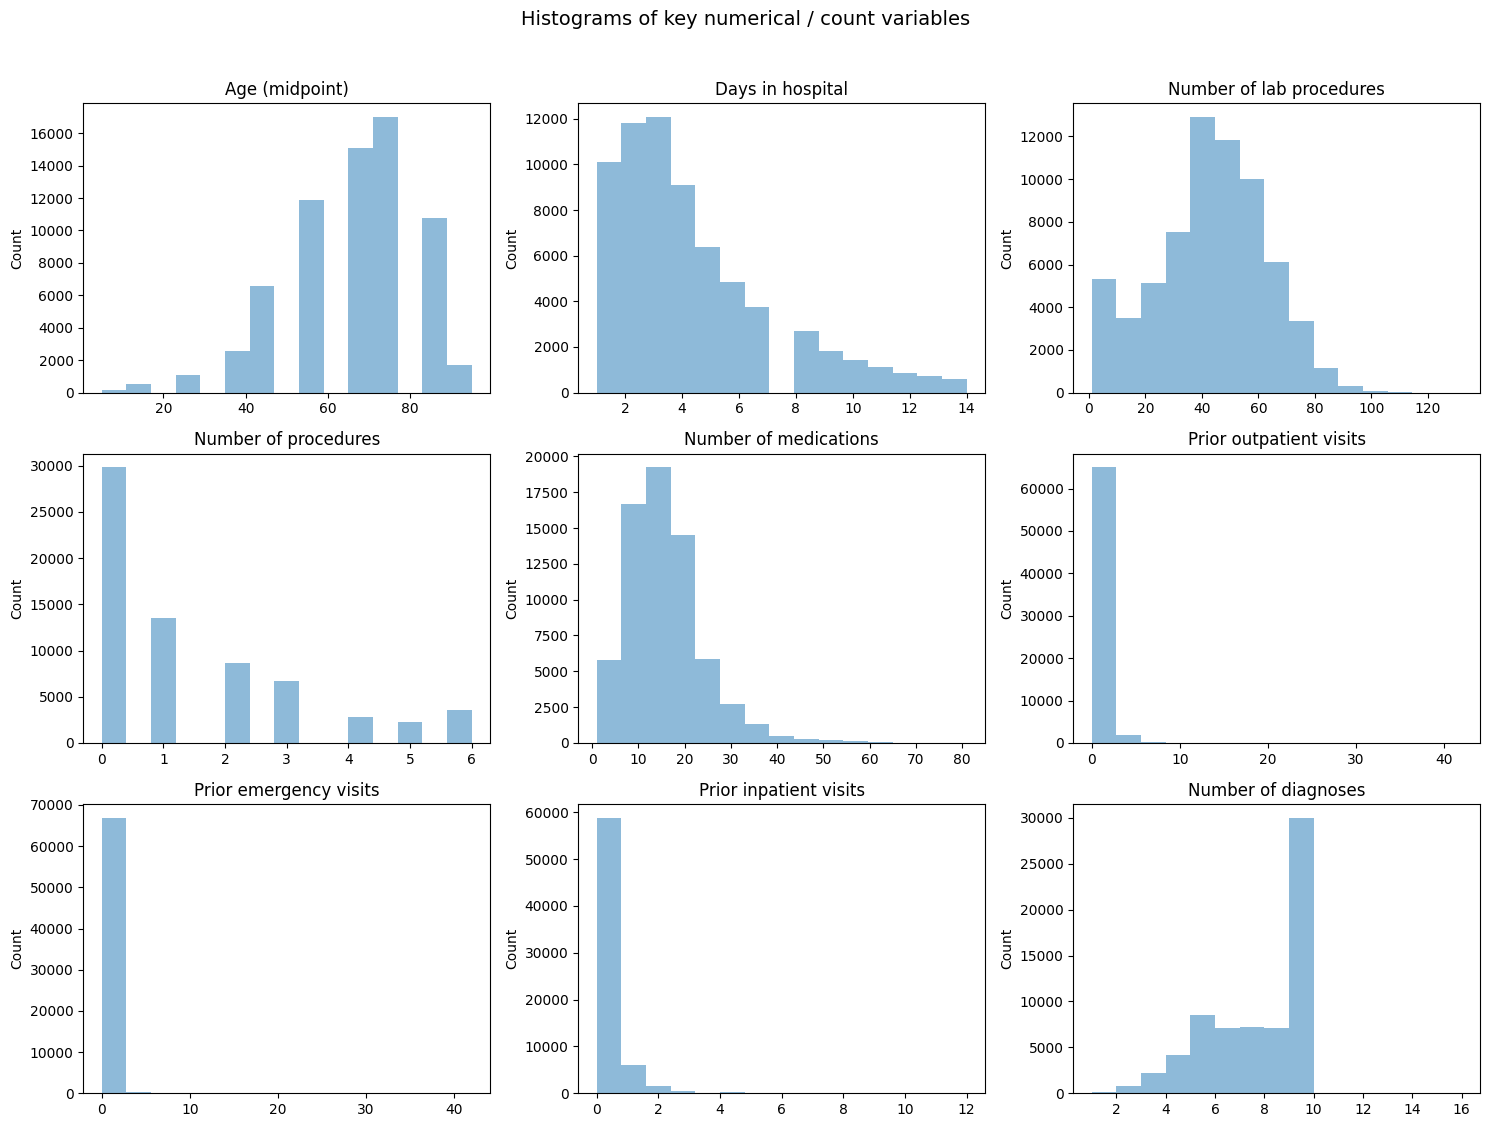

In [67]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    ax.hist(analysis_df[col].dropna(), bins=15, alpha=0.5)
    ax.set_title(numeric_cols.get(col, col))
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.suptitle("Histograms of key numerical / count variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Interpretation
  
To see whether a handful of values dominate the sample, we inspect histograms for the main numerical/count variables used later in the analysis. The goal here is not really normality - it is simply to understand shape, concentration, and whether a few extreme values are driving the summary statistics. We notice the following patterns that matter for the rest of the project:

- **Age** is discrete because it is recorded as interval midpoints rather than exact age, so it should be read as grouped age information rather than a truly continuous measure.
- **Hospital utilisation variables** such as prior outpatient, emergency, and inpatient visits are strongly right-skewed: most patients have few prior visits, but there is a smaller group has a heavier prior use.
- **Length of stay, procedures, and medications** also show right tails, which is clinically plausible because sicker and more complex patients accumulate more interventions, while not all patients are e.g., tested due to a non-severe condition.
- **Diagnoses** shows quite an interesting pattern - it is right skewed, and a mean patient has around 7 diagnoses.
- **Number of lab procedures** - a mean patient has around 42 of those, which seems to be a very high number and is difficult to explain due to lack of clear variable description in the raw dataset.

These shapes suggest that later linear-style models may be influenced by these distributions, so we will be checking robustness and using flexible learners in the ML section.

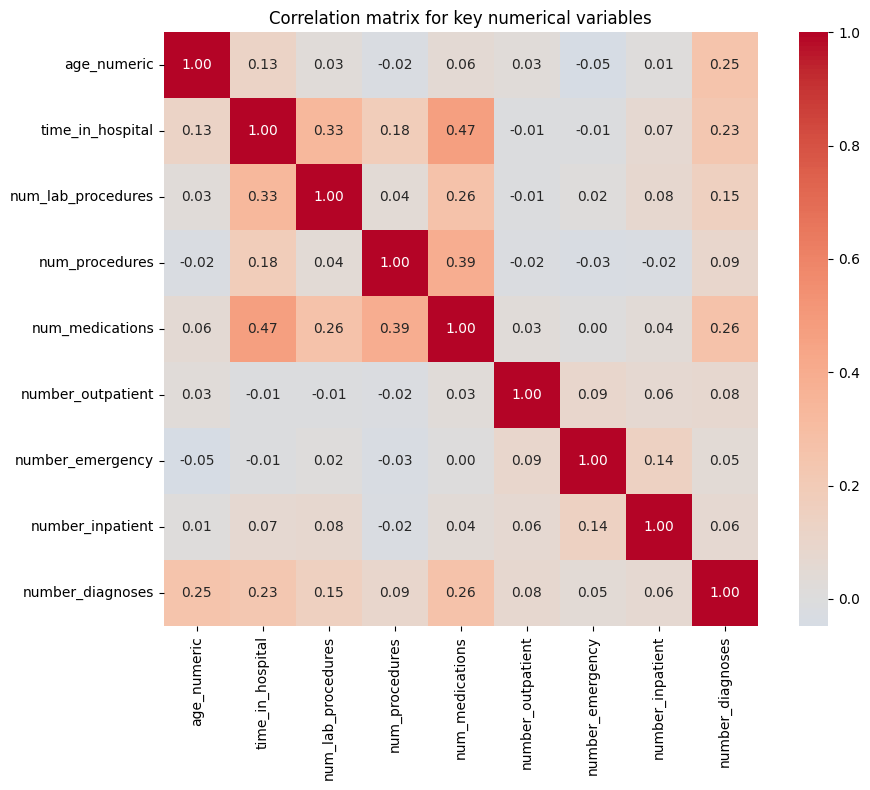

,var_1,var_2,correlation
0,time_in_hospital,num_medications,0.469098
1,num_procedures,num_medications,0.392358
2,time_in_hospital,num_lab_procedures,0.330754
3,num_medications,number_diagnoses,0.263970
4,num_lab_procedures,num_medications,0.262703
5,age_numeric,number_diagnoses,0.253702
6,time_in_hospital,number_diagnoses,0.233011
7,time_in_hospital,num_procedures,0.182271
8,num_lab_procedures,number_diagnoses,0.149447
9,number_emergency,number_inpatient,0.142492


In [68]:
# correlation structure among the main numerical variables

corr_matrix = analysis_df[list(numeric_cols.keys())].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix for key numerical variables")
plt.tight_layout()
plt.show()

corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
)
corr_pairs.columns = ["var_1", "var_2", "correlation"]
display(corr_pairs.head(10))

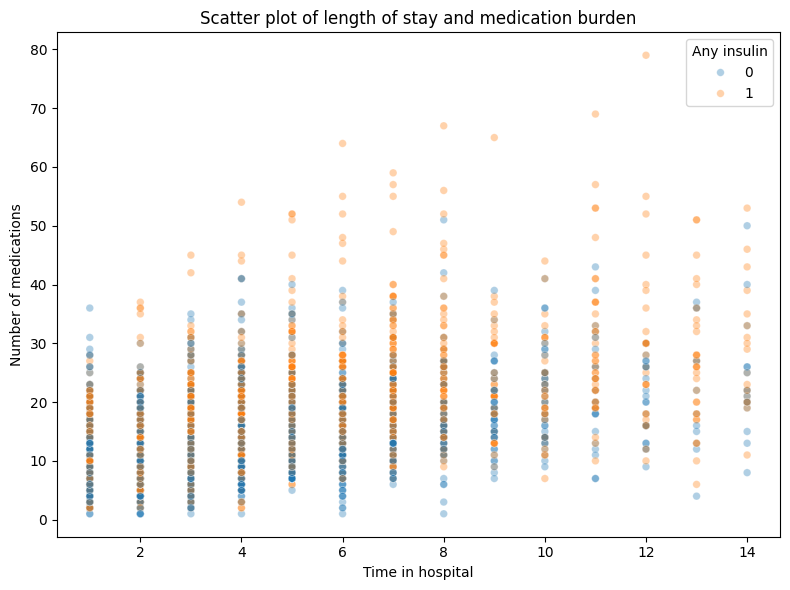

In [69]:
top_x = "time_in_hospital"
top_y = "num_medications"

sample_n = min(4000, len(analysis_df))
plot_df = analysis_df[[top_x, top_y, "readmitted_30", "insulin_any"]].sample(sample_n, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x=top_x,
    y=top_y,
    hue="insulin_any",
    alpha=0.35,
    s=30
)
plt.title("Scatter plot of length of stay and medication burden")
plt.xlabel("Time in hospital")
plt.ylabel("Number of medications")
plt.legend(title="Any insulin")
plt.tight_layout()
plt.show()

### Interpretation

Because several variables are all proxies for underlying illness severity or case complexity, it is useful to inspect how strongly they move together. Indeed, the numerical variables are related, but not strongly.

- The strongest correlation is between **time in hospital** and **number of medications**, which makes intuitive sense: longer stays often involve more treatment changes and more recorded medications.
- Procedure counts, lab procedures, diagnoses, and medication burden are also positively related, again pointing to a common severity/complexity dimension.
- None of the correlations here are close to 1 in absolute value, but this check suggests that our models later will be estimating **conditional** relationships among several partially overlapping severity proxies.

The scatter plot investigates the highest correlation between **time in hospital** and **number of medications**. We observe that patients with longer stays tend to receive more medications, but there is substantial dispersion.

### 1.4 Focusing on treatment regimes - medications

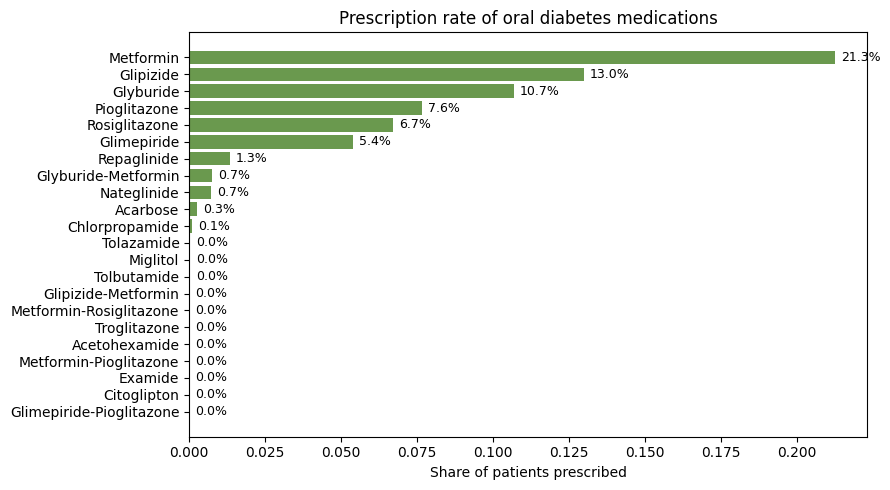

In [70]:
non_insulin_meds = {
    "metformin_binary": "Metformin",
    "glipizide_binary": "Glipizide",
    "glyburide_binary": "Glyburide",
    "pioglitazone_binary": "Pioglitazone",
    "rosiglitazone_binary": "Rosiglitazone",
    "glimepiride_binary": "Glimepiride",
    "repaglinide_binary": "Repaglinide",
    "nateglinide_binary": "Nateglinide",
    "acarbose_binary": "Acarbose",
    "acetohexamide_binary": "Acetohexamide",
    "chlorpropamide_binary": "Chlorpropamide",
    "tolbutamide_binary": "Tolbutamide",
    "miglitol_binary": "Miglitol",
    "troglitazone_binary": "Troglitazone",
    "tolazamide_binary": "Tolazamide",
    "examide_binary": "Examide",
    "citoglipton_binary": "Citoglipton",
    "glyburide-metformin_binary": "Glyburide-Metformin",
    "glipizide-metformin_binary": "Glipizide-Metformin",
    "glimepiride-pioglitazone_binary": "Glimepiride-Pioglitazone",
    "metformin-rosiglitazone_binary": "Metformin-Rosiglitazone",
    "metformin-pioglitazone_binary": "Metformin-Pioglitazone",
}

oral_rates = pd.DataFrame({
    "medication": non_insulin_meds.values(),
    "prescription_rate": [analysis_df[col].mean() for col in non_insulin_meds.keys()]
}).sort_values("prescription_rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(oral_rates["medication"], oral_rates["prescription_rate"], color="#6a994e")
ax.set_title("Prescription rate of oral diabetes medications")
ax.set_xlabel("Share of patients prescribed")
for i, v in enumerate(oral_rates["prescription_rate"]):
    ax.text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Aside from insulin, patients can be prescribed other (oral) diabetes medication. Among them, metformin seems by far to be the most 
commonly prescribed (21%), followed by glipizide (13%) and 
glyburide (11%). These three drugs account for the vast majority 
of oral diabetes medication use in the dataset. 

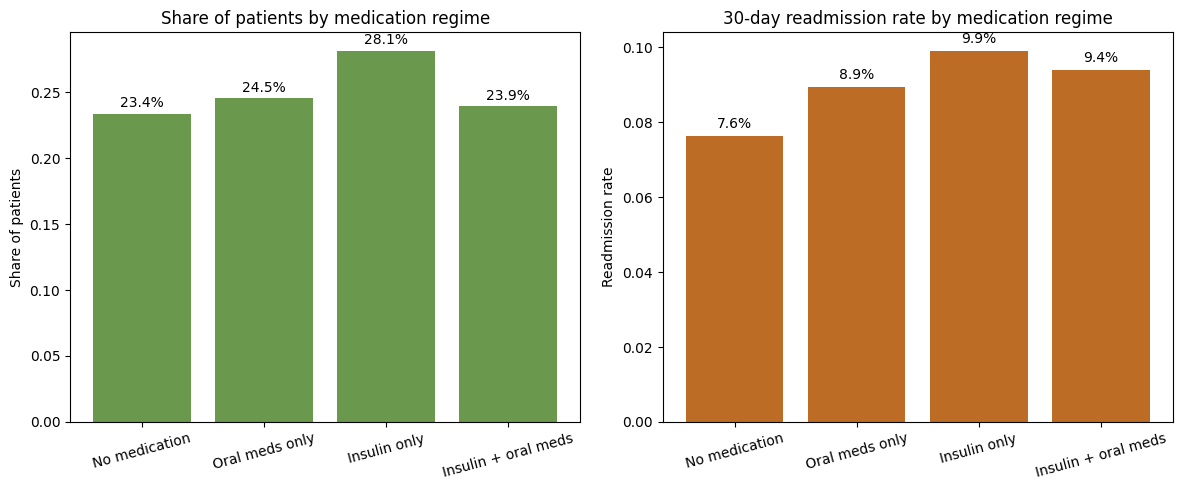

             regime  n_patients    share  readmission_rate
      No medication       15730 0.233677          0.076478
     Oral meds only       16522 0.245443          0.089456
       Insulin only       18944 0.281423          0.099082
Insulin + oral meds       16119 0.239456          0.093988


In [71]:
regime_labels = {
    0: "No medication",
    1: "Oral meds only",
    2: "Insulin only",
    3: "Insulin + oral meds"
}

regime_counts = analysis_df["treatment_multivalued"].value_counts().sort_index()
regime_readmission = analysis_df.groupby("treatment_multivalued")["readmitted_30"].mean()

regime_df = pd.DataFrame({
    "regime": regime_labels.values(),
    "n_patients": regime_counts.values,
    "share": (regime_counts / len(analysis_df)).values,
    "readmission_rate": regime_readmission.values
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(regime_df["regime"], regime_df["share"], color="#6a994e")
axes[0].set_title("Share of patients by medication regime")
axes[0].set_ylabel("Share of patients")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(regime_df["share"]):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontsize=10)

axes[1].bar(regime_df["regime"], regime_df["readmission_rate"], color="#bc6c25")
axes[1].set_title("30-day readmission rate by medication regime")
axes[1].set_ylabel("Readmission rate")
axes[1].tick_params(axis="x", rotation=15)
for i, v in enumerate(regime_df["readmission_rate"]):
    axes[1].text(i, v + 0.002, f"{v:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(regime_df.to_string(index=False))

### Interpretation

The four medication regimes we consider in the analysis (since we focus on insulin) are roughly equally distributed 
across the sample, each representing between 23-28% of patients.

Looking at the raw readmission rates across regimes, we find that the no-medication group has the lowest readmission rate (7.6%). This does not mean that patients not receiving medication are better protected against the risk of readmission. It might simply mean that not needing medication simply correlated with a less severe state which inherently reduces the likelihood of readmission. Admissions in this case may also be due to other factors than diabetes. These are the first signs of the importance to account for counfounding factors.

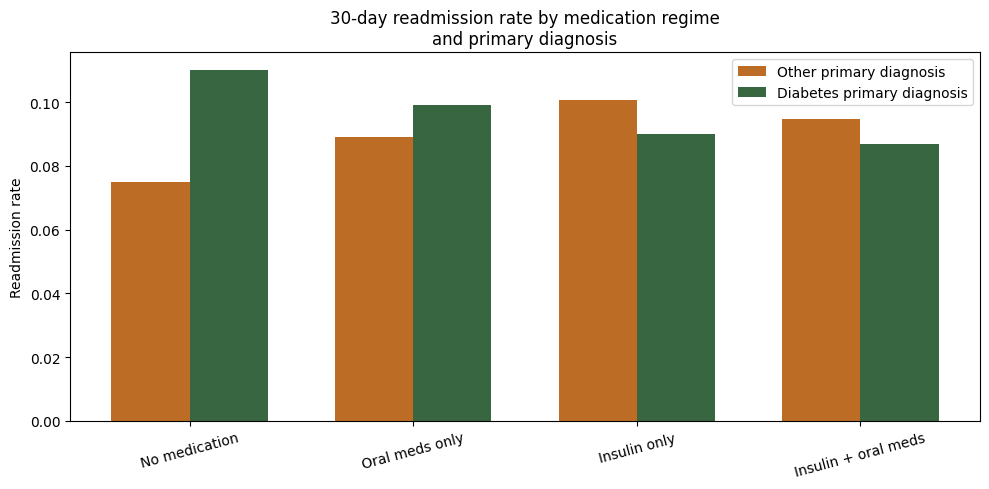

In [72]:
regime_order = ["No medication", "Oral meds only", "Insulin only", "Insulin + oral meds"]

readmit_cross = (
    analysis_df.groupby(["treatment_multivalued", "primary_diag_diabetes"])["readmitted_30"]
    .mean()
    .unstack()
    .rename(index=regime_labels)
    .reindex(regime_order)
    .rename(columns={
        0: "Other primary diagnosis",
        1: "Diabetes primary diagnosis"
    })
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(regime_order))
width = 0.35

ax.bar(x - width/2, readmit_cross["Other primary diagnosis"],
       width, label="Other primary diagnosis", color="#bc6c25")
ax.bar(x + width/2, readmit_cross["Diabetes primary diagnosis"],
       width, label="Diabetes primary diagnosis", color="#386641")

ax.set_title("30-day readmission rate by medication regime\nand primary diagnosis")
ax.set_ylabel("Readmission rate")
ax.set_xticks(x)
ax.set_xticklabels(regime_order, rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

This figure reveals a striking pattern. Among patients receiving 
**no diabetes medication**, those admitted primarily for diabetes 
have the highest readmission rate in the entire figure (11%). It is higher than any medicated group and higher than patients admitted 
for other conditions without medication (7.5%). This suggests that 
diabetic patients admitted specifically because of their diabetes, 
but who receive no active medication management during the stay, 
are at particularly elevated readmission risk.

At face value, this suggests that as medication intensity increases (from no medication to oral 
drugs to insulin), the gap between diabetes-primary and 
other-primary patients shrinks and eventually reverses. Among 
insulin patients, those admitted primarily for diabetes actually 
have *lower* readmission rates than those admitted for other 
conditions.

This pattern is consistent with the idea that active medication 
management specifically benefits patients whose primary problem 
is diabetes, which suggests a posiitve effect of insulin. However, this is a purely descriptive observation. The groups differ in many other ways and no causal claim is 
made here. This motivates the causal analysis in the notebooks 
that follow.

### 1.5 Relevant categorical variables

- **Race** matters because patient populations differ systematically in socioeconomic risk, access, and disease burden.
- **Admission type** and **admission source** proxy urgency and the pathway into the hospital.
- **Payer type** is especially important because the federal government penalises hospitals under **Medicare** for high readmission rates, so the payer mix is substantively relevant.
- **Medical specialty** gives a rough picture of the treating service.

We collapse each dummy family into one summary table with the sample share, raw readmission rate, and insulin-use rate for each category.

In [73]:
def build_dummy_summary(df, prefix, baseline_name=None):
    dummy_cols = [c for c in df.columns if c.startswith(prefix)]
    summary_rows = []

    # rows for each dummy == 1
    for col in dummy_cols:
        mask = df[col] == 1
        summary_rows.append({
            "category": col.replace(prefix, ""),
            "share": mask.mean(),
            "readmission_rate": df.loc[mask, "readmitted_30"].mean(),
            "insulin_rate": df.loc[mask, "insulin_any"].mean(),
        })

    # baseline row: all dummies are 0
    if baseline_name is not None:
        baseline_mask = (df[dummy_cols].sum(axis=1) == 0)
        summary_rows.append({
            "category": baseline_name,
            "share": baseline_mask.mean(),
            "readmission_rate": df.loc[baseline_mask, "readmitted_30"].mean(),
            "insulin_rate": df.loc[baseline_mask, "insulin_any"].mean(),
        })

    out = pd.DataFrame(summary_rows).sort_values("share", ascending=False)
    out["share"] = out["share"].round(3)
    out["readmission_rate"] = out["readmission_rate"].round(3)
    out["insulin_rate"] = out["insulin_rate"].round(3)
    return out


race_summary = build_dummy_summary(analysis_df, "race_", baseline_name="Caucasian")
admission_type_summary = build_dummy_summary(analysis_df, "admission_type_", baseline_name="Emergency")
admission_source_summary = build_dummy_summary(analysis_df, "admission_source_", baseline_name="Emergency")
payer_summary = build_dummy_summary(analysis_df, "payer_", baseline_name="Medicare")
specialty_summary = build_dummy_summary(analysis_df, "specialty_", baseline_name="InternalMedicine")

print("Summary of patient characteristics by race")
display(race_summary)

print("Summary of patient characteristics by admission type")
display(admission_type_summary)

print("Summary of patient characteristics by admission source")
display(admission_source_summary)

print("Summary of patient characteristics by payer type")
display(payer_summary)

print("Summary of patient characteristics by medical specialty")
display(specialty_summary)


Summary of patient characteristics by race


,category,share,readmission_rate,insulin_rate
5,Caucasian,0.747,0.093,0.505
0,AfricanAmerican,0.180,0.086,0.573
4,Unknown,0.028,0.073,0.593
1,Hispanic,0.021,0.080,0.538
3,Other,0.016,0.070,0.564
2,Asian,0.007,0.086,0.448


Summary of patient characteristics by admission type


,category,share,readmission_rate,insulin_rate
3,Emergency,0.513,0.092,0.539
1,Elective,0.195,0.082,0.472
0,Urgent,0.185,0.090,0.548
2,Other,0.107,0.096,0.478


Summary of patient characteristics by admission source


,category,share,readmission_rate,insulin_rate
3,Emergency,0.536,0.093,0.539
0,Referral,0.325,0.087,0.497
2,Other,0.073,0.090,0.472
1,Transfer,0.066,0.084,0.545


Summary of patient characteristics by payer type


,category,share,readmission_rate,insulin_rate
3,Unknown,0.412,0.101,0.468
4,Medicare,0.295,0.094,0.556
2,Other,0.184,0.075,0.600
0,HM,0.059,0.069,0.447
1,BC,0.050,0.060,0.543


Summary of patient characteristics by medical specialty


,category,share,readmission_rate,insulin_rate
5,Unknown,0.474,0.093,0.529
6,InternalMedicine,0.157,0.098,0.548
4,Other,0.141,0.083,0.491
0,Family/GeneralPractice,0.070,0.099,0.509
1,Emergency/Trauma,0.065,0.079,0.607
2,Cardiology,0.061,0.072,0.421
3,Surgery-General,0.032,0.085,0.448


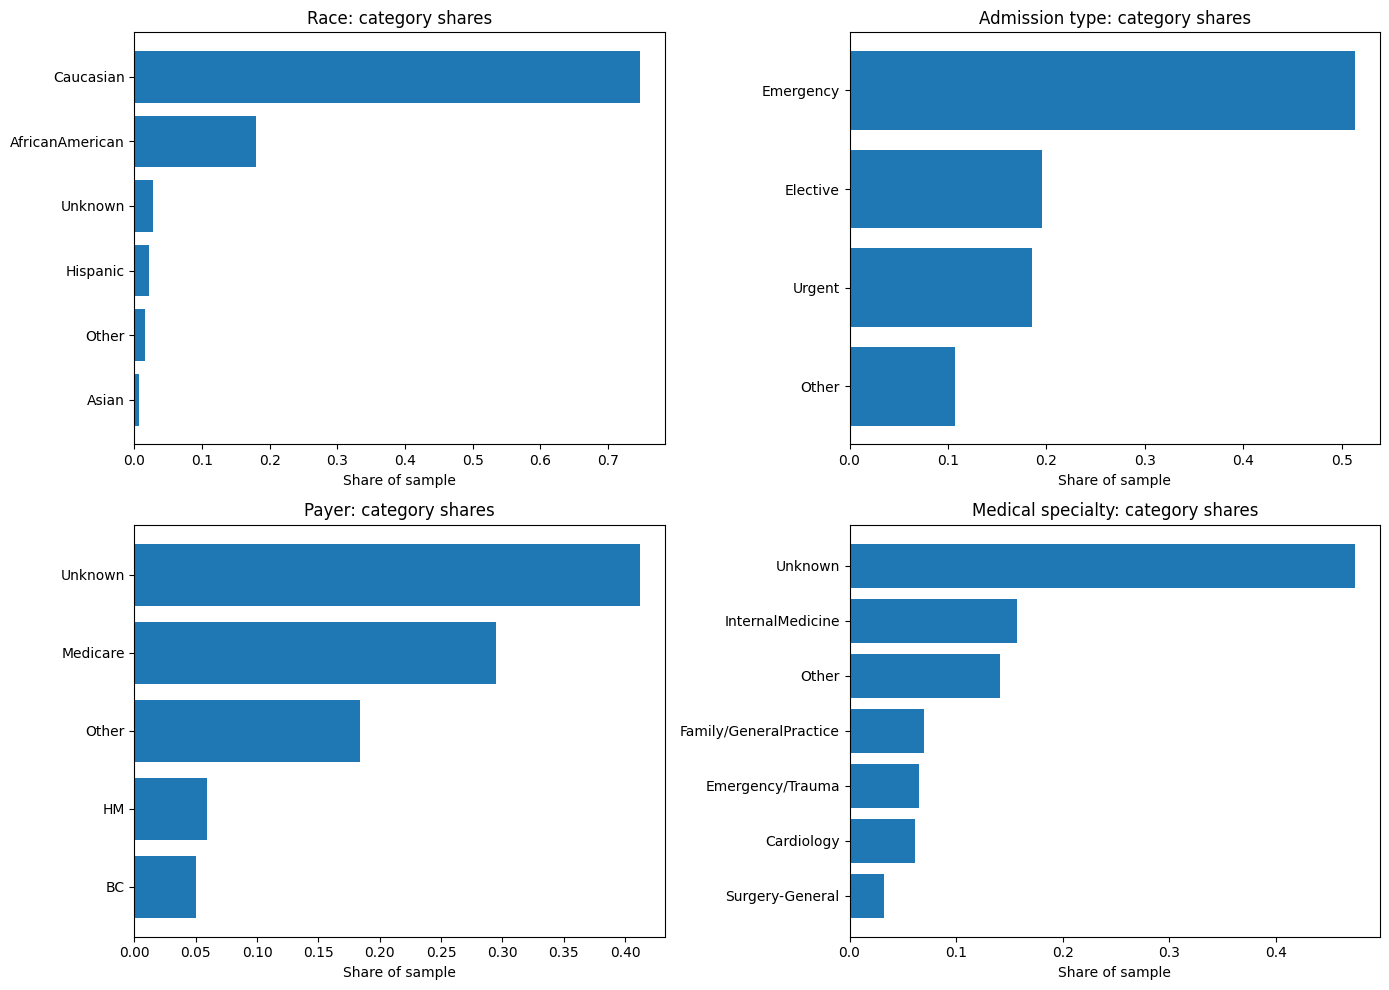

In [74]:
# use admission type (source gives us less information on the case severity)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_tables = [
    ("Race", race_summary, axes[0, 0]),
    ("Admission type", admission_type_summary, axes[0, 1]),
    ("Payer", payer_summary, axes[1, 0]),
    ("Medical specialty", specialty_summary, axes[1, 1]),
]

for title, table, ax in plot_tables:
    plot_df = table.sort_values("share", ascending=True)
    ax.barh(plot_df["category"], plot_df["share"])
    ax.set_title(f"{title}: category shares")
    ax.set_xlabel("Share of sample")

plt.tight_layout()
plt.show()

### Interpretation

A few descriptive facts stand out:

- **Race:** the sample is predominantly **Caucasian**, with **African American** the next-largest race group. Mean readmission rates are also highest for the **Caucasian** group, while the insulin rate is the second lowest (after **Asian**). 

- **Admission type/source:** a large part of the sample enters through the **emergency** pathway rather than planned care. Indeed, urgent or emergency admissions are usually clinically less comparable to elective ones, which is mirrored by the higher insulin (and readmisson) rates for these groups.

- **Payer type:** **Medicare** is one of the largest payer groups (besides **Unknown**), which matters substantively because federal readmission penalties are tied to Medicare. In the data, Medicare patients also have a higher readmission rate than several commercial payer groups, which is consistent with an older and more medically complex population. They also have a higher insulin rate.

- **Medical specialty:** **Internal Medicine** is the largest named specialty, besides **Unknown**. In this category, the insulin rate is the highest for the **Emergency/Trauma** group and the readmission rate is the highest for the **Family/General Practice** followed closely by **Internal Medicine**.

These dummy summaries are descriptive rather than causal. They introduce an institutional context of the readmission question in our models.

## 2. Identifying Confounding Factors

The central identification challenge of this project is that insulin 
is not randomly assigned. Essentially, we are working with a dataset which represents conditions where physicians prescribe insulin potentially to their sickest 
patients given specific guidelines. This means insulin patients and non-insulin patients are 
systematically different on variables that also predict readmission. 
If we simply compare readmission rates between the two groups, we 
are measuring patient severity, not drug effectiveness.

This section demonstrates that confounding by indication is real 
and substantial in this dataset. We show this in four steps:
1. A balance table showing which variables differ most between 
   treated and untreated patients
2. A medication burden comparison reinforcing the largest imbalance
3. A propensity score overlap check assessing whether causal 
   estimation is feasible

### 2.1 Covariates imbalances

In [75]:
# we compute standardised mean differences between insulin and no-insulin patients
# how far apart two groups are in standard deviation units?

balance_cols = [
    "age_numeric",
    "female",
    "weight_observed",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "A1C_tested",
    "A1C_abnormal",
    "glu_tested",
    "glu_abnormal",
    "any_non_insulin_meds",
]

treated = analysis_df[analysis_df["insulin_any"] == 1]
control = analysis_df[analysis_df["insulin_any"] == 0]

balance = pd.DataFrame({
    "variable": balance_cols,
    "treated_mean": [treated[col].mean() for col in balance_cols],
    "control_mean": [control[col].mean() for col in balance_cols],
    "treated_sd": [treated[col].std() for col in balance_cols],
    "control_sd": [control[col].std() for col in balance_cols],
})

balance["pooled_sd"] = np.sqrt(
    (balance["treated_sd"]**2 + balance["control_sd"]**2) / 2
)
balance["smd"] = (
    (balance["treated_mean"] - balance["control_mean"]) / balance["pooled_sd"]
)

balance = balance.sort_values("smd")
print(balance[["variable", "treated_mean", "control_mean", "smd"]].round(3).to_string(index=False))

            variable  treated_mean  control_mean    smd
     weight_observed         0.022         0.061 -0.195
         age_numeric        64.108        66.921 -0.177
any_non_insulin_meds         0.460         0.512 -0.105
          glu_tested         0.044         0.052 -0.037
              female         0.532         0.534 -0.004
   number_outpatient         0.286         0.290 -0.004
      num_procedures         1.439         1.381  0.033
    number_inpatient         0.208         0.172  0.056
        glu_abnormal         0.028         0.018  0.063
    number_emergency         0.123         0.090  0.064
    number_diagnoses         7.388         7.111  0.140
          A1C_tested         0.223         0.141  0.213
  num_lab_procedures        44.947        40.711  0.213
    time_in_hospital         4.567         3.905  0.229
        A1C_abnormal         0.168         0.088  0.240
     num_medications        17.276        13.893  0.423


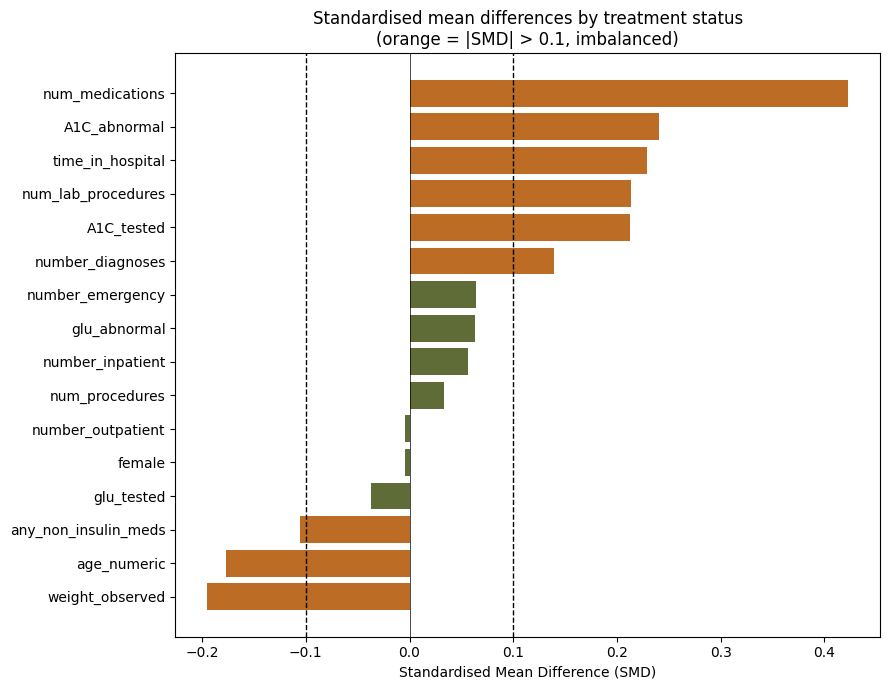

In [76]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = np.where(balance["smd"].abs() >= 0.1, "#bc6c25", "#606c38")
ax.barh(balance["variable"], balance["smd"], color=colors)
ax.axvline(0.1, linestyle="--", color="black", linewidth=1)
ax.axvline(-0.1, linestyle="--", color="black", linewidth=1)
ax.axvline(0, linestyle="-", color="black", linewidth=0.5)
ax.set_title("Standardised mean differences by treatment status\n(orange = |SMD| > 0.1, imbalanced)")
ax.set_xlabel("Standardised Mean Difference (SMD)")
plt.tight_layout()
plt.show()

### Interpretation

We compare two groups of patients: those who received any insulin 
prescription during their hospital stay (**treated group**, D=1, 
52% of patients) and those who received no insulin (**control 
group**, D=0, 48% of patients). The plot shows standardised 
mean differences (SMD) between these two groups for each covariate. 
An SMD above 0.1 in absolute value (marked by dashed lines) 
indicates meaningful imbalance.

Several variables show large imbalances:

- **num_medications (SMD = 0.42)** - insulin patients take far 
  more medications, reflecting greater clinical complexity
- **A1C_abnormal (SMD = 0.24)** - insulin patients have more 
  frequently abnormal HbA1c (a blood test measuring average blood sugar levels over the past 2–3 months), confirming worse glycaemic control, but they are also tested more
- **num_lab_procedures (SMD = 0.22)** - insulin patients undergo 
  more lab tests, indicating more intensive monitoring
- **time_in_hospital (SMD = 0.21)** - insulin patients stay longer
- **weight_observed (SMD = -0.18)** - non-insulin patients are 
  more likely to have weight recorded
- **age_numeric (SMD = -0.18)** - insulin patients are younger 
  on average
- **any_non_insulin_meds (SMD = -0.11)** - non-insulin patients 
  are more likely to be on oral medications

These imbalances confirm that a naive comparison of readmission 
rates between the treated and control groups would be deeply 
misleading. The two groups are clinically very different before 
any outcome is observed. This proves that there are important confounding factors, 
which is why we need Double Machine Learning.

### 2.2 Medication burden comparison 

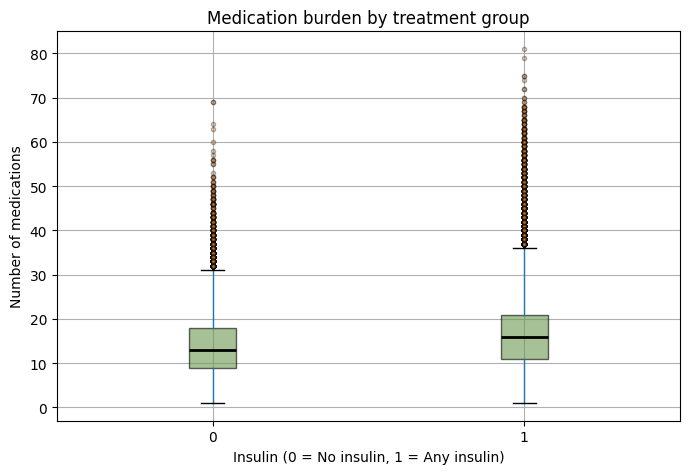

Mean medications - No insulin: 13.9
Mean medications - Any insulin: 17.3


In [77]:
fig, ax = plt.subplots(figsize=(7, 5))

analysis_df.boxplot(
    column="num_medications",
    by="insulin_any",
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="#6a994e", alpha=0.6),
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markerfacecolor="#bc6c25", markersize=3, alpha=0.3)
)

ax.set_title("Medication burden by treatment group")
ax.set_xlabel("Insulin (0 = No insulin, 1 = Any insulin)")
ax.set_ylabel("Number of medications")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"Mean medications - No insulin: {control['num_medications'].mean():.1f}")
print(f"Mean medications - Any insulin: {treated['num_medications'].mean():.1f}")

### Interpretation

The medication burden boxplot makes the largest imbalance from 
the previous plot immediately visible. Insulin patients receive on 
average **17 different medications** during their stay compared 
to **14 for non-insulin patients**.

Number of medications is one of the strongest clinical proxies 
for patient complexity of status. Essentially, a patient managing 17 drugs 
simultaneously has more comorbidities, more active conditions 
to treat, and a more fragile overall health status than a 
patient on 14. This is direct evidence that insulin is being 
prescribed to sicker patients. **This also shows that physicians are not randomly 
deciding who gets insulin, but they are rather giving it to the patients 
who need it most, precisely because those patients are the most 
severely ill.**

This is the confounding by indication problem in its most 
concrete form. **A patient on 17 medications is more likely to 
be readmitted regardless of whether they receive insulin, 
simply because they are sicker.** Any unadjusted comparison of 
readmission rates between the two groups therefore captures 
patient severity, not drug effectiveness. This is why naive 
OLS gives the wrong answer, and why we need Double Machine 
Learning to strip out this severity confounding before 
estimating the causal effect.

## 3. Heterogeneity Analysis

We focus the heterogeneity analysis on variables that are especially plausible from a clinical or policy perspective: **age**, **gender**, **prior hospitalisation**, **payer type (especially Medicare)**, and **markers of diabetic monitoring/severity such as A1C testing**.

If all patients responded to insulin identically, a single average treatment effect would be sufficient. But if the effect differs systematically across patient groups, then the ATE alone is incomplete. The figures below are still descriptive rather than causal: they show where treatment patterns and raw readmission differences look especially heterogeneous.

### 3.1 Age

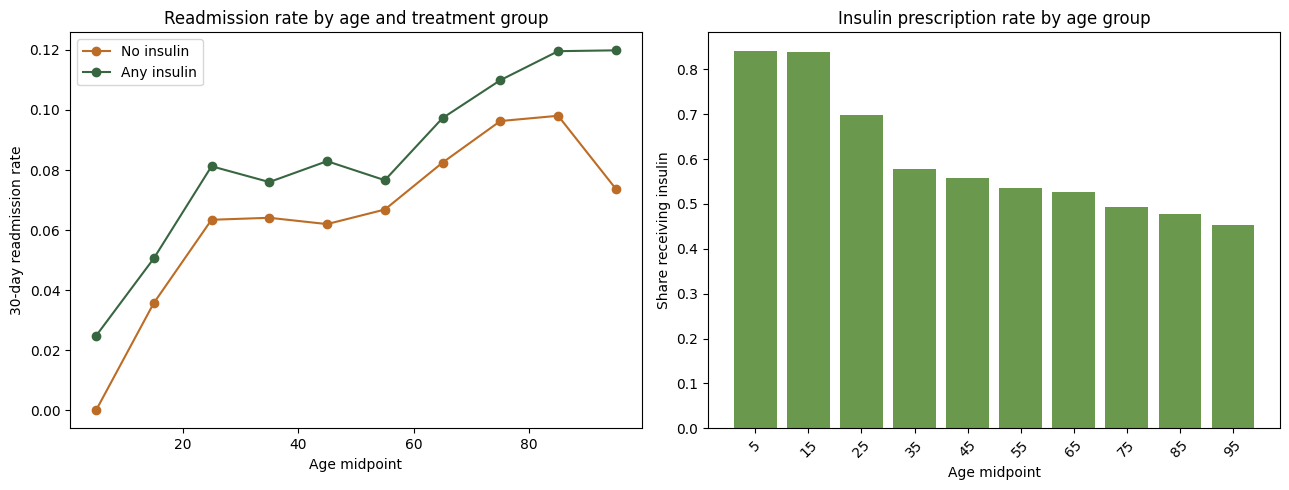

In [79]:
age_readmit = (
    analysis_df.groupby(["age_numeric", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

insulin_by_age = analysis_df.groupby("age_numeric")["insulin_any"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: readmission rate by age and treatment group
for treat, color, label in [
    (0, "#bc6c25", "No insulin"), 
    (1, "#386641", "Any insulin")
]:
    sub = age_readmit[age_readmit["insulin_any"] == treat]
    axes[0].plot(sub["age_numeric"], sub["readmitted_30"], 
                 marker="o", color=color, label=label)

axes[0].set_title("Readmission rate by age and treatment group")
axes[0].set_xlabel("Age midpoint")
axes[0].set_ylabel("30-day readmission rate")
axes[0].legend()

# right: insulin prescription rate by age
axes[1].bar(insulin_by_age.index.astype(str), insulin_by_age.values, 
            color="#6a994e")
axes[1].set_title("Insulin prescription rate by age group")
axes[1].set_xlabel("Age midpoint")
axes[1].set_ylabel("Share receiving insulin")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Two striking patterns emerge across age groups.

First, **insulin prescription rates fall sharply with age**, 
from over 80% in the youngest patients to around 45% in 
patients over 80. Older patients are less likely to receive 
insulin, possibly because of greater concern about health risk in elderly patients.

Second, **readmission rates rise with age** for both *no insulin* and *any insulin* groups. But the gap between insulin and non-insulin patients widens 
at older ages. This is again another confounding factor to accoutn for linked to heterogeneity in ages: older insulin patients seem to be more ill and likely to be readmitted to a hospital.

The fact that insulin prescription rate falls with age while readmission rate rises suggest that the relationship between insulin and readmission is age-dependent. This 
motivates age as the primary heterogeneity dimension in a CATE analysis.


### 3.2 Gender

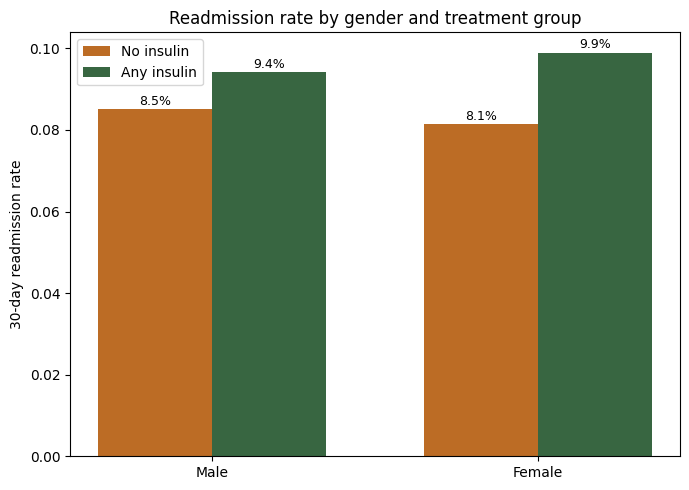

In [80]:
gender_readmit = (
    analysis_df.groupby(["female", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)
gender_readmit["gender"] = gender_readmit["female"].map({0: "Male", 1: "Female"})

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(2)
width = 0.35
labels = ["Male", "Female"]

no_insulin = gender_readmit[gender_readmit["insulin_any"] == 0]["readmitted_30"].values
any_insulin = gender_readmit[gender_readmit["insulin_any"] == 1]["readmitted_30"].values

ax.bar(x - width/2, no_insulin, width, label="No insulin", color="#bc6c25")
ax.bar(x + width/2, any_insulin, width, label="Any insulin", color="#386641")
ax.set_title("Readmission rate by gender and treatment group")
ax.set_ylabel("30-day readmission rate")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i, v in enumerate(no_insulin):
    ax.text(i - width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)
for i, v in enumerate(any_insulin):
    ax.text(i + width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

Men and women show marginally different readmission patterns. The gap between insulin and non-insulin patients is similar across genders in the raw data. The differences here are small in absolute terms. Whether gender impacts the causal effect of insulin is a question left for futher exploration through a CATE analysis.

### 3.3 Prior hospitalization

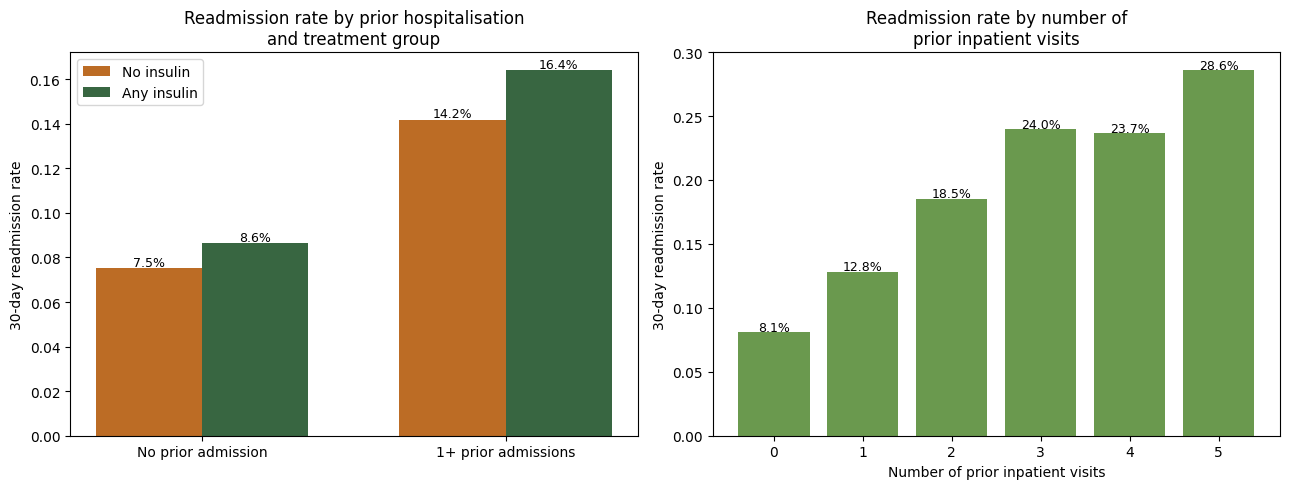

In [81]:
# Create prior hospitalisation binary
analysis_df["any_prior_inpatient"] = (analysis_df["number_inpatient"] > 0).astype(int)

prior_readmit = (
    analysis_df.groupby(["any_prior_inpatient", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: readmission rate by prior hospitalisation and treatment
x = np.arange(2)
width = 0.35
labels = ["No prior admission", "1+ prior admissions"]

no_insulin = prior_readmit[prior_readmit["insulin_any"]==0]["readmitted_30"].values
any_insulin = prior_readmit[prior_readmit["insulin_any"]==1]["readmitted_30"].values

axes[0].bar(x - width/2, no_insulin, width, label="No insulin", color="#bc6c25")
axes[0].bar(x + width/2, any_insulin, width, label="Any insulin", color="#386641")
axes[0].set_title("Readmission rate by prior hospitalisation\nand treatment group")
axes[0].set_ylabel("30-day readmission rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()
for i, v in enumerate(no_insulin):
    axes[0].text(i - width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)
for i, v in enumerate(any_insulin):
    axes[0].text(i + width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)

# Right: readmission rate by number of prior inpatient visits
prior_counts = (
    analysis_df.groupby("number_inpatient")["readmitted_30"]
    .mean()
    .reset_index()
    .query("number_inpatient <= 5")
)
axes[1].bar(prior_counts["number_inpatient"].astype(str), 
            prior_counts["readmitted_30"], color="#6a994e")
axes[1].set_title("Readmission rate by number of\nprior inpatient visits")
axes[1].set_xlabel("Number of prior inpatient visits")
axes[1].set_ylabel("30-day readmission rate")
for i, v in enumerate(prior_counts["readmitted_30"]):
    axes[1].text(i, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

Prior hospitalisation history seems to be the strongest heterogeneity dimension in the raw data.

**Patients with at least one prior inpatient admission have substantially higher readmission rates than first-time patients**, regardless of whether they receive insulin. These could be described as the "revolving door" patients with poorly controlled chronic diabetes who repeatedly return to hospital.

The right panel shows that **readmission risk increases with the number of prior inpatient visits**, as patients with 3 or more prior admissions face readmission 
rates more than twice those of first-time patients.

This pattern strongly motivates prior hospitalisation as a key heterogeneity dimension. However, it should be noted that we only included first patient encounter in the dataset, which negatively impacts the causal interpretability for this section. It would be better to study repeated or last patient visit for this case.


### 3.4 Payer type and the Medicare policy context

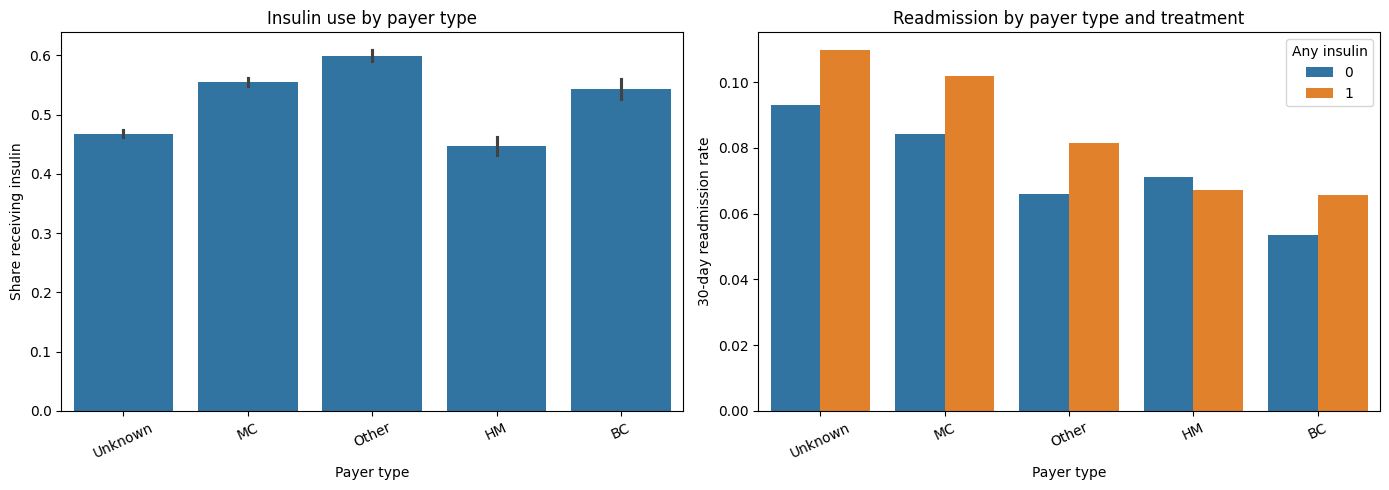

In [82]:
payer_cols = analysis_df.filter(regex="^payer_").columns

payer_long = analysis_df.assign(
    payer_type=np.where(
        analysis_df[payer_cols].sum(axis=1) == 0,
        "MC",
        analysis_df[payer_cols].idxmax(axis=1).str.replace("payer_", "", regex=False)
    )
)

payer_order = (
    payer_long.groupby("payer_type").size().sort_values(ascending=False).index.tolist()
)

payer_plot = (
    payer_long.groupby(["payer_type", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=payer_long,
    x="payer_type",
    y="insulin_any",
    estimator=np.mean,
    order=payer_order,
    ax=axes[0]
)
axes[0].set_title("Insulin use by payer type")
axes[0].set_xlabel("Payer type")
axes[0].set_ylabel("Share receiving insulin")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(
    data=payer_plot,
    x="payer_type",
    y="readmitted_30",
    hue="insulin_any",
    order=payer_order,
    ax=axes[1]
)
axes[1].set_title("Readmission by payer type and treatment")
axes[1].set_xlabel("Payer type")
axes[1].set_ylabel("30-day readmission rate")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Any insulin")

plt.tight_layout()
plt.show()

### Interpretation

**Medicare patients form a large group and also exhibit comparatively high readmission rates**, which is consistent with the fact that the Medicare population is older and medically more complex on average.

Insulin use also varies meaningfully across payer categories. That does not tell us whether insulin is effective or ineffective, but it reinforces the need to control for institutional and patient-composition differences rather than comparing treated and untreated patients as if assignment were random.

### 3.5 Admission pathway

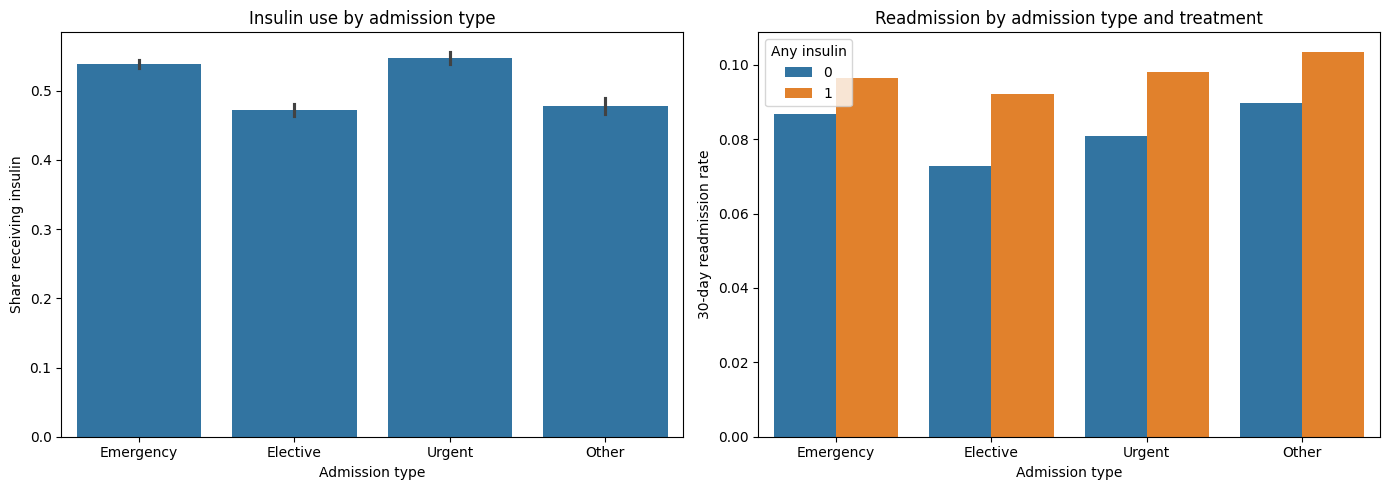

In [83]:
admission_type_cols = analysis_df.filter(regex="^admission_type_").columns

admission_type_long = analysis_df.assign(
    admission_type=np.where(
        analysis_df[admission_type_cols].sum(axis=1) == 0,
        "Emergency",
        analysis_df[admission_type_cols]
        .idxmax(axis=1)
        .str.replace("admission_type_", "", regex=False)
    )
)

admission_plot = (
    admission_type_long.groupby(["admission_type", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

type_order = (
    admission_type_long.groupby("admission_type")
    .size()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=admission_type_long,
    x="admission_type",
    y="insulin_any",
    estimator=np.mean,
    order=type_order,
    ax=axes[0]
)
axes[0].set_title("Insulin use by admission type")
axes[0].set_xlabel("Admission type")
axes[0].set_ylabel("Share receiving insulin")

sns.barplot(
    data=admission_plot,
    x="admission_type",
    y="readmitted_30",
    hue="insulin_any",
    order=type_order,
    ax=axes[1]
)
axes[1].set_title("Readmission by admission type and treatment")
axes[1].set_xlabel("Admission type")
axes[1].set_ylabel("30-day readmission rate")
axes[1].legend(title="Any insulin")

plt.tight_layout()
plt.show()

### Interpretation

Emergency and urgent admissions look slightly different from elective admissions in both insulin treatment rates and readmission risk. That is exactly what we would expect if admission pathway partly captures severity and health instability.

### 3.6 Diabetic monitoring and test results

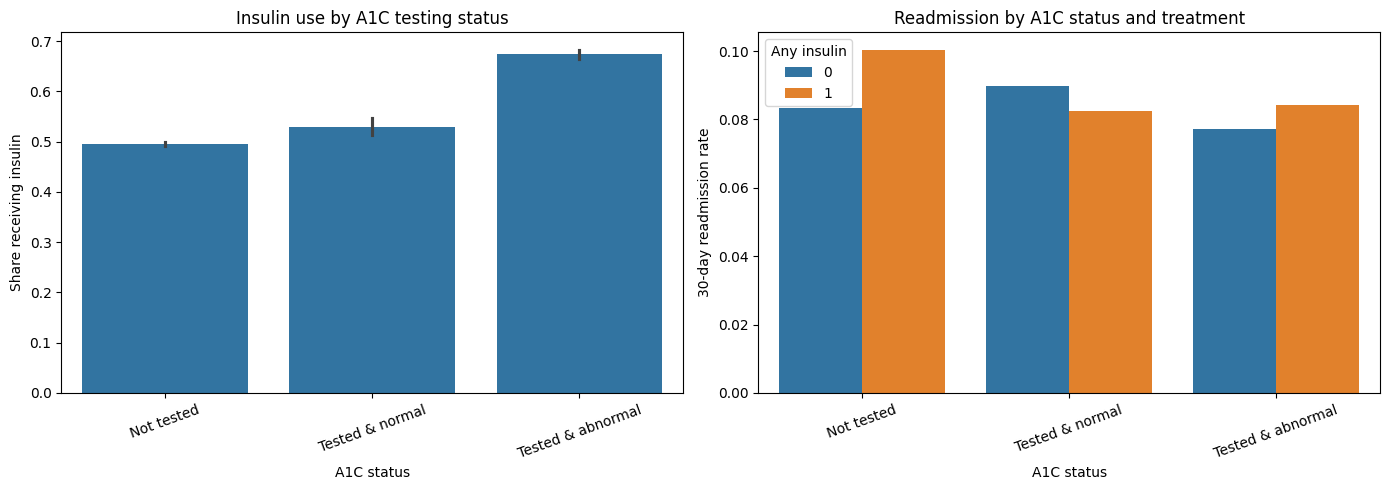

In [84]:
a1c_status = np.select(
    [
        (analysis_df["A1C_tested"] == 0),
        (analysis_df["A1C_tested"] == 1) & (analysis_df["A1C_abnormal"] == 0),
        (analysis_df["A1C_tested"] == 1) & (analysis_df["A1C_abnormal"] == 1),
    ],
    [
        "Not tested",
        "Tested & normal",
        "Tested & abnormal",
    ],
    default="Other"
)

a1c_df = analysis_df.assign(A1C_status=a1c_status)

a1c_plot = (
    a1c_df.groupby(["A1C_status", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

status_order = ["Not tested", "Tested & normal", "Tested & abnormal"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=a1c_df,
    x="A1C_status",
    y="insulin_any",
    estimator=np.mean,
    order=status_order,
    ax=axes[0]
)
axes[0].set_title("Insulin use by A1C testing status")
axes[0].set_xlabel("A1C status")
axes[0].set_ylabel("Share receiving insulin")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=a1c_plot,
    x="A1C_status",
    y="readmitted_30",
    hue="insulin_any",
    order=status_order,
    ax=axes[1]
)
axes[1].set_title("Readmission by A1C status and treatment")
axes[1].set_xlabel("A1C status")
axes[1].set_ylabel("30-day readmission rate")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Any insulin")

plt.tight_layout()
plt.show()

### Interpretation

A1C information is interesting because it is partly a **severity signal** and partly a **testing/monitoring decision**. Patients with an abnormal (tested) A1C receive insulin more than patients that are not tested or that have normal levels of A1C, which is clinically intuitive. Interestingly, the readmission rates are highest for patients who were no tested for A1C and received insulin anyways, which may suggest that conducting the tests is a good practice to reduce readmission rates. 

### 3.7 Weight observed - our monitoring intensity proxy

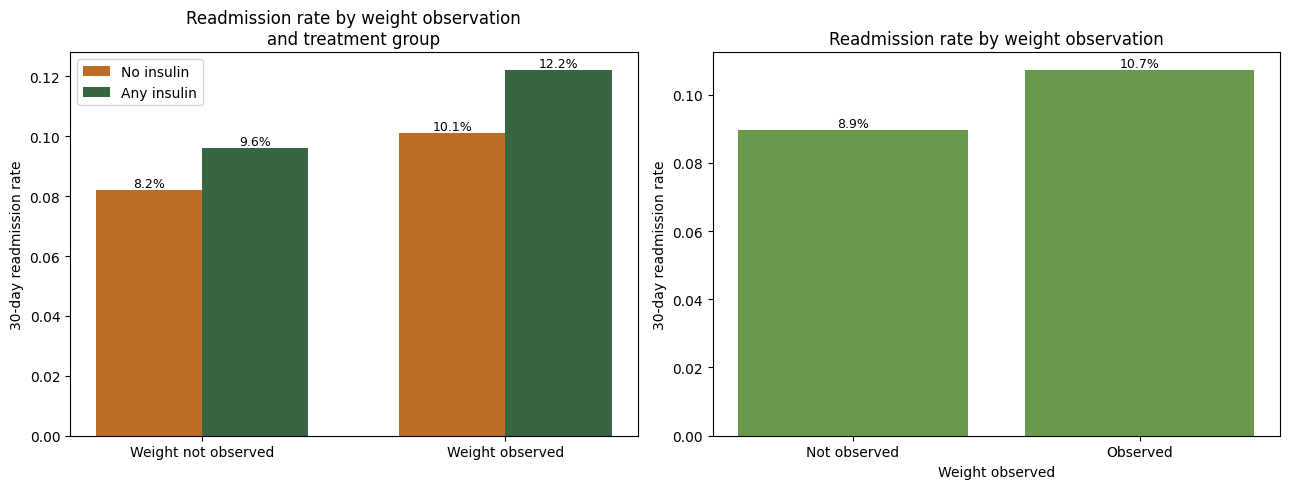

In [86]:
weight_readmit = (
    analysis_df.groupby(["weight_observed", "insulin_any"])["readmitted_30"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: readmission rate by weight observed and treatment
x = np.arange(2)
width = 0.35
labels = ["Weight not observed", "Weight observed"]

no_insulin = weight_readmit[weight_readmit["insulin_any"] == 0]["readmitted_30"].values
any_insulin = weight_readmit[weight_readmit["insulin_any"] == 1]["readmitted_30"].values

axes[0].bar(x - width/2, no_insulin, width, label="No insulin", color="#bc6c25")
axes[0].bar(x + width/2, any_insulin, width, label="Any insulin", color="#386641")
axes[0].set_title("Readmission rate by weight observation\nand treatment group")
axes[0].set_ylabel("30-day readmission rate")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].legend()

for i, v in enumerate(no_insulin):
    axes[0].text(i - width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)
for i, v in enumerate(any_insulin):
    axes[0].text(i + width/2, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)

# Right: overall readmission rate by weight observed
weight_counts = (
    analysis_df.groupby("weight_observed")["readmitted_30"]
    .mean()
    .reset_index()
)

axes[1].bar(
    weight_counts["weight_observed"].map({0: "Not observed", 1: "Observed"}),
    weight_counts["readmitted_30"],
    color="#6a994e"
)
axes[1].set_title("Readmission rate by weight observation")
axes[1].set_xlabel("Weight observed")
axes[1].set_ylabel("30-day readmission rate")

for i, v in enumerate(weight_counts["readmitted_30"]):
    axes[1].text(i, v + 0.001, f"{v:.1%}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation 

For weight recorded, patients have in general higher readmission rates both when they are treated and not treated. This gives the intuition for weight_observed as out monitoring intensity proxy that can also signify the severity of the patient's state. Our intuition is: patient's in worse general state are being monitored more closely and also they would in general we readmitted more often.